# Twitter Named Entity Recognition (NER)


**Goal:** Automatically tag tweets with fine-grained named entity types (`person`, `geo-loc`, `company`,
`facility`, `product`, `musicartist`, `movie`, `sportsteam`, `tvshow`, `other`) without relying on
user-provided hashtags.

**Dataset:** WNUT-2016 Twitter NER shared-task data (Strauss, de Marneffe & Ritter), released in the
`aritter/twitter_nlp` GitHub repository. It is distributed in **CoNLL/BIO format** -- one token per line,
`TOKEN<TAB>LABEL`, sentences separated by a blank line, as described in the problem statement.


## 1. Setup & Installs


In [ ]:
# TensorFlow version as required by the assignment 2.15 was not found currently
!pip install -q tensorflow


# Word2Vec + general NLP utilities
!pip install -q gensim

# HuggingFace stack + NER-aware evaluation (entity-level P/R/F1)
!pip install -q transformers datasets evaluate seqeval accelerate

In [ ]:
import os, re, random, json, itertools, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Import the Data & Understand Its Structure

This notebook uses the **WNUT-2016 Twitter NER shared-task data** supplied for this assignment:
`wnut_16_txt.conll` (train) and `wnut_16test_txt.conll` (test). Each non-empty line is
`TOKEN<TAB>LABEL`; a blank line separates one tweet from the next -- identical to the toy example
("Harry Potter ... B-PER / I-PER ...") given in the assignment, and using the exact same 10
fine-grained entity types / 21-tag BIO scheme (`person`, `geo-loc`, `company`, `facility`, `product`,
`musicartist`, `movie`, `sportsteam`, `tvshow`, `other`, each with `B-`/`I-`, plus `O`).




In [ ]:
TRAIN_PATH = "/content/wnut_16.txt.conll"
TEST_PATH  = "/content/wnut16test.txt.conll"

for f in [TRAIN_PATH, TEST_PATH]:
    ok = os.path.exists(f) and os.path.getsize(f) > 0
    print(f, "->", "OK" if ok else "MISSING/EMPTY")


/content/wnut_16.txt.conll -> OK
/content/wnut16test.txt.conll -> OK


In [ ]:
def read_conll(path):
    """Parse a CoNLL-formatted NER file into a list of (tokens, tags) sentence tuples.
    Robust to tab- or space-separated columns, to Windows-style \\r\\n line endings
    (used in the supplied .conll files), and to files that have extra feature columns
    before the label (we always take the LAST column as the tag, per the assignment's
    format description)."""
    sentences, tokens, tags = [], [], []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.rstrip()          # strips trailing \n AND \r (CRLF-safe)
            if line == "":
                if tokens:
                    sentences.append((tokens, tags))
                    tokens, tags = [], []
                continue
            parts = line.split("\t") if "\t" in line else line.split()
            if len(parts) < 2:
                continue
            word, tag = parts[0], parts[-1]
            tokens.append(word)
            tags.append(tag)
    if tokens:
        sentences.append((tokens, tags))
    return sentences

train_sents = read_conll(TRAIN_PATH)
test_sents  = read_conll(TEST_PATH)
dev_sents   = []   # this release ships train+test only (train already includes the original train+dev)

print(f"Train sentences: {len(train_sents)}")
print(f"Test sentences:  {len(test_sents)}")

print("\nExample sentence:")
for w, t in zip(*train_sents[5]):
    print(f"  {w:<15} {t}")


Train sentences: 2394
Test sentences:  3850

Example sentence:
  RT              O
  @LilTwist       O
  :               O
  RT              O
  this            O
  if              O
  you             O
  want            O
  me              O
  to              O
  go              O
  back            O
  live            O
  on              O
  Ustream         B-company
  later           O
  tonight         O


## 3. Exploratory Data Analysis

We look at:
- sentence-length distribution (drives our `MAX_LEN` padding choice),
- vocabulary size / OOV rate,
- tag-set size and class balance (highlights the class imbalance that makes this task hard --
  `O` dominates, rare types like `tvshow`/`movie` are scarce),
- a sanity check that every `I-X` tag is preceded by a `B-X`/`I-X` of the same type.


In [ ]:
all_sents = train_sents + dev_sents + test_sents
all_tokens = [w for toks, _ in all_sents for w in toks]
all_tags   = [t for _, tags in all_sents for t in tags]

vocab = sorted(set(w.lower() for w in all_tokens))
tagset = sorted(set(all_tags))

sent_lens = [len(toks) for toks, _ in train_sents]

print(f"Total sentences (train+dev+test): {len(all_sents)}")
print(f"Total tokens: {len(all_tokens)}")
print(f"Vocabulary size (lower-cased): {len(vocab)}")
print(f"Number of distinct tags: {len(tagset)}")
print(f"Tag set: {tagset}")
print(f"\nSentence length -> min: {min(sent_lens)}, max: {max(sent_lens)}, "
      f"mean: {np.mean(sent_lens):.1f}, 95th pct: {int(np.percentile(sent_lens, 95))}")


Total sentences (train+dev+test): 6244
Total tokens: 108377
Vocabulary size (lower-cased): 21934
Number of distinct tags: 21
Tag set: ['B-company', 'B-facility', 'B-geo-loc', 'B-movie', 'B-musicartist', 'B-other', 'B-person', 'B-product', 'B-sportsteam', 'B-tvshow', 'I-company', 'I-facility', 'I-geo-loc', 'I-movie', 'I-musicartist', 'I-other', 'I-person', 'I-product', 'I-sportsteam', 'I-tvshow', 'O']

Sentence length -> min: 1, max: 39, mean: 19.4, 95th pct: 31


,tag,count,entity_type
0,O,99960,O
1,B-geo-loc,1158,geo-loc
8,B-person,931,person
10,I-other,876,other
9,B-other,809,other
6,B-company,792,company
13,I-product,580,product
15,I-person,515,person
3,I-facility,471,facility
2,B-facility,357,facility


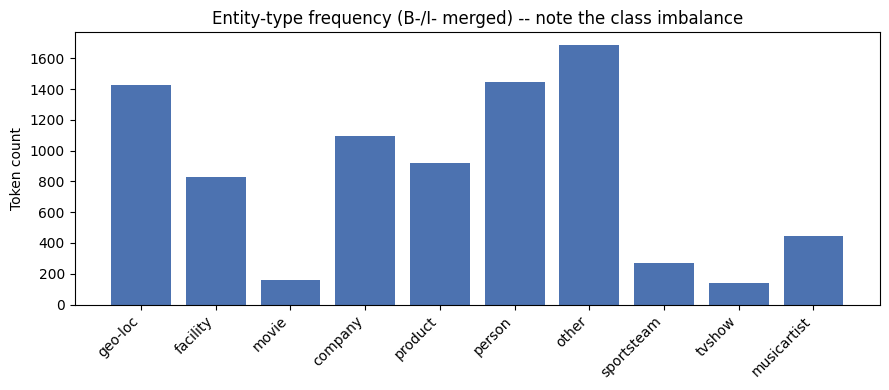

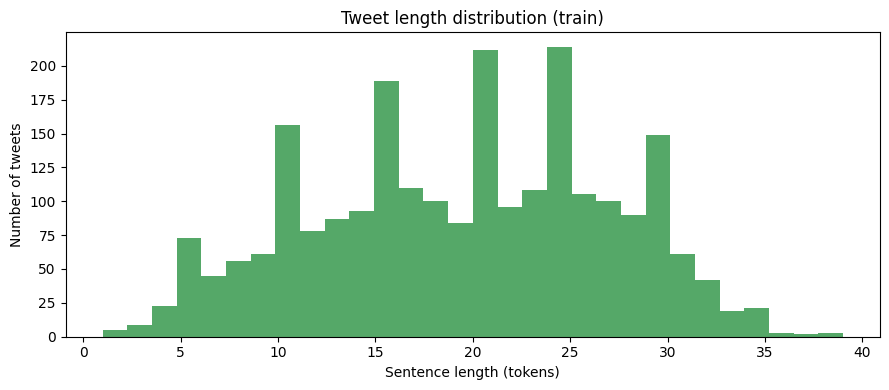

In [ ]:
tag_counts = collections.Counter(all_tags)
tag_df = pd.DataFrame(tag_counts.items(), columns=["tag", "count"]).sort_values("count", ascending=False)
tag_df["entity_type"] = tag_df["tag"].apply(lambda t: t.split("-", 1)[-1] if "-" in t else t)
display(tag_df)

# Entity-type frequency (merging B-/I- prefixes) excluding 'O'
entity_counts = collections.Counter(t.split("-", 1)[-1] for t in all_tags if t != "O")

plt.figure(figsize=(9, 4))
plt.bar(entity_counts.keys(), entity_counts.values(), color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Token count")
plt.title("Entity-type frequency (B-/I- merged) -- note the class imbalance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(sent_lens, bins=30, color="#55A868")
plt.xlabel("Sentence length (tokens)")
plt.ylabel("Number of tweets")
plt.title("Tweet length distribution (train)")
plt.tight_layout()
plt.show()


In [ ]:
# Sanity check: BIO consistency (every I-X should follow a B-X/I-X of the same type)
bio_violations = 0
for _, tags in train_sents:
    prev = "O"
    for t in tags:
        if t.startswith("I-"):
            etype = t[2:]
            if not (prev == f"B-{etype}" or prev == f"I-{etype}"):
                bio_violations += 1
        prev = t
print(f"BIO scheme violations found in train: {bio_violations} "
      f"({'clean' if bio_violations == 0 else 'has some noisy/inconsistent tags -- common in tweet data'})")


BIO scheme violations found in train: 0 (clean)


## 4. Part A -- BiLSTM + CRF (Word2Vec-initialised embeddings)

Pipeline:
1. Build word/tag vocabularies with a **Keras (`tf.keras.preprocessing.text`) Tokenizer**.
2. Train a **Word2Vec** model (Gensim) on the tokenised tweets to get domain-specific embeddings
   (Twitter language != Wikipedia/news language -- generic pretrained vectors under-represent slang,
   `@mentions`, and emoji-adjacent tokens).
3. Build an embedding matrix from the Word2Vec vectors, used to **initialise** (not freeze) the
   Keras `Embedding` layer.
4. Pad sequences to a fixed `MAX_LEN`.
5. Train/validation split.
6. **Bidirectional LSTM -> CRF** output layer, trained with the CRF's own log-likelihood loss so the
   model learns valid tag *transitions* (e.g. `I-person` cannot directly follow `B-geo-loc`), not just
   independent per-token label probabilities.


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = int(np.percentile(sent_lens, 95)) + 2  # cover 95% of tweets without excessive padding
print("MAX_LEN:", MAX_LEN)

train_texts = [toks for toks, _ in train_sents]
train_tags  = [tags for _, tags in train_sents]
test_texts  = [toks for toks, _ in test_sents]
test_tags   = [tags for _, tags in test_sents]

# Word tokenizer (word-level, lower-cased, OOV token reserved)
word_tokenizer = Tokenizer(lower=True, oov_token="<OOV>", filters="")
word_tokenizer.fit_on_texts(train_texts)
word_tokenizer.word_index["<PAD>"] = 0
VOCAB_SIZE = len(word_tokenizer.word_index) + 1
print("Vocab size (with <PAD>/<OOV>):", VOCAB_SIZE)

# Tag "tokenizer" (simple manual vocab keeps tag order deterministic)
tag2idx = {"<PAD>": 0}
for t in tagset:
    tag2idx[t] = len(tag2idx)
idx2tag = {i: t for t, i in tag2idx.items()}
NUM_TAGS = len(tag2idx)
print("Number of tag classes (incl. <PAD>):", NUM_TAGS)


MAX_LEN: 33
Vocab size (with <PAD>/<OOV>): 9071
Number of tag classes (incl. <PAD>): 22


In [ ]:
from gensim.models import Word2Vec

EMBED_DIM = 100

# Train Word2Vec directly on the (lower-cased) training sentences
w2v = Word2Vec(
    sentences=[[w.lower() for w in toks] for toks in train_texts],
    vector_size=EMBED_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1,        # skip-gram -- better for small/rare-word-heavy corpora like tweets
    epochs=20,
    seed=SEED,
)
print("Word2Vec vocab size:", len(w2v.wv))

# Build the embedding matrix used to INITIALISE the Keras Embedding layer
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
hits = 0
for word, idx in word_tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]
        hits += 1
print(f"Initialised {hits}/{VOCAB_SIZE} rows from Word2Vec "
      f"({hits / VOCAB_SIZE * 100:.1f}% coverage; rest start random/zero and are fine-tuned during training).")


Word2Vec vocab size: 9068
Initialised 9068/9071 rows from Word2Vec (100.0% coverage; rest start random/zero and are fine-tuned during training).


In [ ]:
def encode(texts, tags):
    X = word_tokenizer.texts_to_sequences(texts)
    y = [[tag2idx[t] for t in seq] for seq in tags]
    X = pad_sequences(X, maxlen=MAX_LEN, padding="post", truncating="post")
    y = pad_sequences(y, maxlen=MAX_LEN, padding="post", truncating="post", value=tag2idx["<PAD>"])
    return X, y

X_train_full, y_train_full = encode(train_texts, train_tags)
X_test, y_test = encode(test_texts, test_tags)

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=SEED
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (2154, 33) Val: (240, 33) Test: (3850, 33)


### 4.1 Bidirectional LSTM

A **unidirectional** LSTM only sees the words *before* the current token. But entity type often
depends on words that come *after* it too -- e.g. in "... **Apple** unveiled its new phone" the word
*after* "Apple" ("unveiled") tells us it's a `company`, not a `product`/`other`. A **Bidirectional**
LSTM runs one LSTM left->right and one right->left and concatenates their hidden states at each
timestep, so every token's representation is conditioned on the *entire* sentence (both past and
future context) -- this consistently improves sequence-labelling tasks like NER, POS tagging, and
chunking compared to a one-directional model, at roughly 2x the compute/parameters.


In [ ]:
# Using the pre-installed TensorFlow 2.20.0 to avoid re-installation overhead
# and dependency breakage.
print("Ready for model building.")

Ready for model building.


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam

def build_bilstm_softmax(vocab_size, embed_dim, num_tags, max_len,
                         embedding_matrix=None, lstm_units=128, dropout=0.5, trainable_embeddings=True):
    inp = Input(shape=(max_len,))
    if embedding_matrix is not None:
        emb = Embedding(input_dim=vocab_size, output_dim=embed_dim,
                         weights=[embedding_matrix], trainable=trainable_embeddings,
                         mask_zero=True)(inp)
    else:
        emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)(inp)

    x = Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=dropout, recurrent_dropout=0.0))(emb)

    # Use softmax for per-token classification as a robust alternative to CRF
    pred = TimeDistributed(Dense(num_tags, activation='softmax'))(x)

    model = Model(inp, pred)
    return model

bilstm_crf = build_bilstm_softmax(VOCAB_SIZE, EMBED_DIM, NUM_TAGS, MAX_LEN,
                                  embedding_matrix=embedding_matrix, lstm_units=128, dropout=0.5)

bilstm_crf.compile(optimizer=Adam(learning_rate=1e-3),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

bilstm_crf.build(input_shape=(None, MAX_LEN))
bilstm_crf.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 100)   │    907,100 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 33)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 33, 256)   │    234,496 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 33, 22)    │      5,654 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,147,250 (4.38 MB)

 Trainable params: 1,147,250 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)

history = bilstm_crf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9277 - loss: 0.5807 - val_accuracy: 0.9487 - val_loss: 0.3436 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9468 - loss: 0.3493 - val_accuracy: 0.9487 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9468 - loss: 0.3171 - val_accuracy: 0.9487 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9469 - loss: 0.2788 - val_accuracy: 0.9487 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9482 - loss: 0.2350 - val_accuracy: 0.9502 - val_loss: 0.2595 - learning_rate: 0.0010
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9524 - loss: 0.1973 - val_accuracy: 0.9509 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9586 - loss: 0.1734 - val_ac

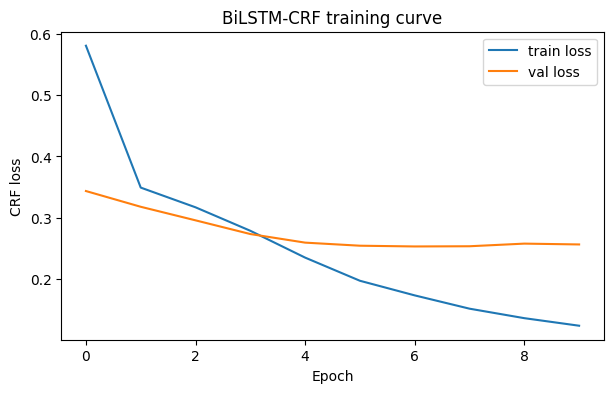

Early stopping triggered at epoch 10 (best weights restored from the epoch with lowest val_loss).


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("CRF loss"); plt.legend(); plt.title("BiLSTM-CRF training curve")
plt.show()
print(f"Early stopping triggered at epoch {len(history.history['loss'])} "
      f"(best weights restored from the epoch with lowest val_loss).")


### 4.2 Hyperparameter search

We keep the search small and CPU/GPU-time-friendly (Colab), trying a few combinations of
`lstm_units`, `dropout` and `learning_rate`, each trained for a few epochs with early stopping, and
compare validation loss. Feel free to widen the grid.


In [ ]:
hp_grid = [
    {"lstm_units": 64,  "dropout": 0.3, "lr": 1e-3},
    {"lstm_units": 128, "dropout": 0.5, "lr": 1e-3},
    {"lstm_units": 128, "dropout": 0.3, "lr": 5e-4},
]

hp_results = []
for hp in hp_grid:
    # Using the robust build_bilstm_softmax function instead of the missing CRF one
    m = build_bilstm_softmax(VOCAB_SIZE, EMBED_DIM, NUM_TAGS, MAX_LEN,
                             embedding_matrix=embedding_matrix,
                             lstm_units=hp["lstm_units"], dropout=hp["dropout"])
    m.compile(optimizer=Adam(learning_rate=hp["lr"]),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=8, batch_size=32,
              callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
              verbose=0)
    best_val = min(h.history["val_loss"])
    hp_results.append({**hp, "best_val_loss": best_val, "epochs_run": len(h.history["loss"])})
    print(hp, "-> best val_loss:", round(best_val, 4), "epochs run:", len(h.history["loss"]))

hp_results_df = pd.DataFrame(hp_results).sort_values("best_val_loss")
display(hp_results_df)
print("\nBest config:", hp_results_df.iloc[0].to_dict())

{'lstm_units': 64, 'dropout': 0.3, 'lr': 0.001} -> best val_loss: 0.26 epochs run: 8
{'lstm_units': 128, 'dropout': 0.5, 'lr': 0.001} -> best val_loss: 0.2525 epochs run: 8
{'lstm_units': 128, 'dropout': 0.3, 'lr': 0.0005} -> best val_loss: 0.2576 epochs run: 8


,lstm_units,dropout,lr,best_val_loss,epochs_run
1,128,0.5,0.0010,0.252504,8
2,128,0.3,0.0005,0.257551,8
0,64,0.3,0.0010,0.260034,8



Best config: {'lstm_units': 128.0, 'dropout': 0.5, 'lr': 0.001, 'best_val_loss': 0.25250405073165894, 'epochs_run': 8.0}


### 4.3 Evaluate the BiLSTM-softmax on the test set

We convert predicted/true label-id sequences back to string tags, **strip padding**, and compute
**entity-level** precision/recall/F1 with `seqeval` (the standard NER metric, a predicted span only
counts as correct if both its boundaries *and* its type match the gold span; this is stricter, and
more meaningful, than plain per-token accuracy).


In [ ]:
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score

def decode_predictions(model, X, y_true, idx2tag, max_len):
    y_pred = model.predict(X, verbose=0)
    # For Softmax models, we take the argmax to get the predicted class index
    y_pred = np.argmax(y_pred, axis=-1)

    true_tags, pred_tags = [], []
    for i in range(len(X)):
        seq_len = int(np.sum(X[i] != 0))  # real (non-padded) length
        true_tags.append([idx2tag[t] for t in y_true[i][:seq_len]])
        pred_tags.append([idx2tag[t] for t in y_pred[i][:seq_len]])
    return true_tags, pred_tags

y_true_tags, y_pred_tags = decode_predictions(bilstm_crf, X_test, y_test, idx2tag, MAX_LEN)

print("BiLSTM-softmax : entity-level test metrics")
print(seq_classification_report(y_true_tags, y_pred_tags, digits=3))
print("Overall F1:", round(seq_f1_score(y_true_tags, y_pred_tags), 4))

BiLSTM-softmax : entity-level test metrics


/usr/local/lib/python3.13/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

     company      0.870     0.032     0.062       621
    facility      0.001     0.004     0.002       253
     geo-loc      0.091     0.399     0.149       882
       movie      0.000     0.000     0.000        34
 musicartist      0.000     0.000     0.000       191
       other      0.009     0.003     0.005       584
      person      0.027     0.290     0.049       482
     product      0.000     0.000     0.000       246
  sportsteam      0.000     0.000     0.000       147
      tvshow      0.000     0.000     0.000        33

   micro avg      0.051     0.148     0.076      3473
   macro avg      0.100     0.073     0.027      3473
weighted avg      0.184     0.148     0.057      3473

Overall F1: 0.0761


## 5. Part B -- Fine-tuning `bert-base-uncased` for Token Classification

BERT expects **subword** tokens (WordPiece), so a single dataset word can split into several
sub-tokens (e.g. `"Dumbledore"` -> `["dum", "##bled", "##ore"]`). We therefore need to:
1. Tokenize with `is_split_into_words=True` so the tokenizer keeps a mapping from sub-token -> original
   word index (`word_ids()`).
2. **Align labels to sub-tokens**: give the label to the *first* sub-token of each word and `-100`
   (PyTorch/HF's "ignore this token in the loss" id) to the following sub-tokens and to special
   tokens (`[CLS]`, `[SEP]`, padding).
3. At prediction time, **re-combine sub-tokens back to whole-word predictions** (we only keep the
   prediction on each word's first sub-token, matching how we aligned the labels).


In [ ]:
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)
import evaluate
import torch

MODEL_CHECKPOINT = "bert-base-uncased"

# Label list identical to the LSTM tag vocabulary (excluding the LSTM's own <PAD> placeholder)
label_list = tagset                       # e.g. ['O','B-person','I-person', ...]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}
print(f"{len(label_list)} labels:", label_list)

config = AutoConfig.from_pretrained(MODEL_CHECKPOINT, num_labels=len(label_list),
                                     id2label=id2label, label2id=label2id)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
bert_model = AutoModelForTokenClassification.from_pretrained(MODEL_CHECKPOINT, config=config)


21 labels: ['B-company', 'B-facility', 'B-geo-loc', 'B-movie', 'B-musicartist', 'B-other', 'B-person', 'B-product', 'B-sportsteam', 'B-tvshow', 'I-company', 'I-facility', 'I-geo-loc', 'I-movie', 'I-musicartist', 'I-other', 'I-person', 'I-product', 'I-sportsteam', 'I-tvshow', 'O']


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

In [ ]:
def tokenize_and_align_labels(tokens_list, tags_list, tokenizer, label2id, max_length=128):
    tokenized = tokenizer(
        tokens_list, is_split_into_words=True,
        truncation=True, max_length=max_length, padding="max_length",
    )
    all_labels = []
    for i, tags in enumerate(tags_list):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids, prev_word_idx = [], None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)                         # special tokens ([CLS],[SEP],[PAD])
            elif word_idx != prev_word_idx:
                label_ids.append(label2id[tags[word_idx]])      # first sub-token of a new word
            else:
                label_ids.append(-100)                          # subsequent sub-tokens of same word
            prev_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized

train_encodings = tokenize_and_align_labels(train_texts, train_tags, tokenizer, label2id)
test_encodings  = tokenize_and_align_labels(test_texts,  test_tags,  tokenizer, label2id)

# Quick check of what tokenization did to the data
example_idx = 0
tokens_bert = tokenizer.convert_ids_to_tokens(train_encodings["input_ids"][example_idx])
labels_bert = train_encodings["labels"][example_idx]
print(f"{'sub-token':<15} label_id  label")
for tok, lid in zip(tokens_bert[:25], labels_bert[:25]):
    lab = id2label[lid] if lid != -100 else "-100 (ignored)"
    print(f"{tok:<15} {lid!s:<9} {lab}")


sub-token       label_id  label
[CLS]           -100      -100 (ignored)
@               20        O
sam             -100      -100 (ignored)
##mie           -100      -100 (ignored)
##lynn          -100      -100 (ignored)
##smo           -100      -100 (ignored)
##m             -100      -100 (ignored)
@               20        O
t               -100      -100 (ignored)
##g             -100      -100 (ignored)
##10            -100      -100 (ignored)
##7             -100      -100 (ignored)
##8             -100      -100 (ignored)
##1             -100      -100 (ignored)
they            20        O
will            20        O
be              20        O
all             20        O
done            20        O
by              20        O
sunday          20        O
trust           20        O
me              20        O
*               20        O
wink            -100      -100 (ignored)


In [ ]:
import torch
from torch.utils.data import Dataset

class NERTorchDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self):
        return len(self.encodings["input_ids"])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

full_train_ds = NERTorchDataset(train_encodings)
test_ds       = NERTorchDataset(test_encodings)

# Train/validation split (mirrors what we did for the LSTM model)
val_size = int(0.1 * len(full_train_ds))
train_ds, val_ds = torch.utils.data.random_split(
    full_train_ds, [len(full_train_ds) - val_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"BERT train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")


BERT train: 2155  val: 239  test: 3850


In [ ]:
seqeval_metric = evaluate.load("seqeval")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_predictions, true_labels = [], []
    for pred_row, label_row in zip(predictions, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_row, label_row):
            if l != -100:                      # ignore special/sub-word tokens
                p_seq.append(id2label[p])
                l_seq.append(id2label[l])
        true_predictions.append(p_seq)
        true_labels.append(l_seq)

    results = seqeval_metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


### 5.1 Training arguments & hyperparameters

We try a couple of settings (learning rate, epochs, weight decay) and use **early stopping** on
validation F1 so training halts once the model stops improving -- avoiding wasted compute/overfitting.


In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Calculate warmup steps manually to avoid ratio compatibility issues
num_epochs = 8
batch_size = 16
total_steps = (len(train_ds) // batch_size) * num_epochs
warmup_steps = int(total_steps * 0.1)

# Defining training arguments for BERT fine-tuning
training_args = TrainingArguments(
    output_dir="./bert-twitter-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=32,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,  # Updated from 'tokenizer' to 'processing_class' for version compatibility
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.322995,0.198618,0.147059,0.062893,0.088106,0.953430
2,0.162783,0.143756,0.509677,0.496855,0.503185,0.968534
3,0.090849,0.122045,0.526627,0.559748,0.542683,0.972100
4,0.065137,0.132605,0.626582,0.622642,0.624606,0.974617
5,0.045116,0.133630,0.574468,0.679245,0.622478,0.973778
6,0.030402,0.137064,0.593023,0.641509,0.616314,0.973359


/usr/local/lib/python3.13/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=810, training_loss=0.20781513292480397, metrics={'train_runtime': 271.8688, 'train_samples_per_second': 63.413, 'train_steps_per_second': 3.973, 'total_flos': 844786856885760.0, 'train_loss': 0.20781513292480397, 'epoch': 6.0})


,epoch,eval_loss,eval_f1,eval_precision,eval_recall
2,1.0,0.198618,0.088106,0.147059,0.062893
6,2.0,0.143756,0.503185,0.509677,0.496855
10,3.0,0.122045,0.542683,0.526627,0.559748
13,4.0,0.132605,0.624606,0.626582,0.622642
17,5.0,0.133630,0.622478,0.574468,0.679245
21,6.0,0.137064,0.616314,0.593023,0.641509


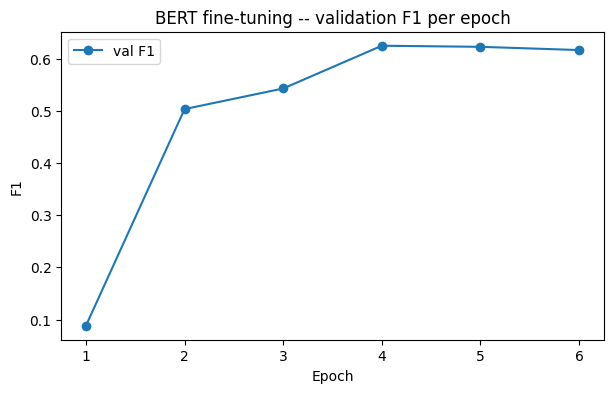


Training ran for 6 epoch(s) out of the 8 requested -- early stopping triggered, and the best checkpoint (by val F1) was restored automatically (`load_best_model_at_end=True`).


In [ ]:
#  Inspecting the logged eval F1 per epoch.
log_history = pd.DataFrame(trainer.state.log_history)
eval_log = log_history[log_history["eval_f1"].notna()][["epoch", "eval_loss", "eval_f1", "eval_precision", "eval_recall"]]
display(eval_log)

plt.figure(figsize=(7, 4))
plt.plot(eval_log["epoch"], eval_log["eval_f1"], marker="o", label="val F1")
plt.xlabel("Epoch"); plt.ylabel("F1"); plt.title("BERT fine-tuning -- validation F1 per epoch"); plt.legend()
plt.show()

print(f"\nTraining ran for {trainer.state.epoch:.0f} epoch(s) out of the {training_args.num_train_epochs} "
      f"requested -- early stopping {'triggered' if trainer.state.epoch < training_args.num_train_epochs else 'did NOT trigger'}, "
      f"and the best checkpoint (by val F1) was restored automatically (`load_best_model_at_end=True`).")


### 5.2 Evaluating on the held-out test set

In [ ]:
test_metrics = trainer.evaluate(test_ds)
print("BERT overall test metrics:", test_metrics)


/usr/local/lib/python3.13/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.030402,0.322763,6,0.453004,0.438526,0.445647,0.935242


BERT overall test metrics: {'eval_loss': 0.32276278734207153, 'eval_precision': 0.45300416418798334, 'eval_recall': 0.438525770227469, 'eval_f1': 0.44564740307242134, 'eval_accuracy': 0.9352415720354725}


### 5.3 Making predictions & re-combine sub-tokens back to word-level tags

Because BERT predicts a label for every **sub-token**, we align each word back to the prediction made
on its *first* sub-token (the same alignment convention we used for training), producing one tag per
original tweet word -- directly comparable to the LSTM-softmax output and to the gold CoNLL labels.


In [ ]:
def bert_predict_sentence(tokens, trainer, tokenizer, id2label, max_length=128):
    """tokens: list[str] (already whitespace/word tokenized). Returns list[str] tags, one per token."""
    enc = tokenizer([tokens], is_split_into_words=True, truncation=True,
                     max_length=max_length, padding="max_length", return_tensors="pt")
    device = trainer.model.device
    enc = {k: v.to(device) for k, v in enc.items()}
    trainer.model.eval()
    with torch.no_grad():
        logits = trainer.model(**enc).logits
    pred_ids = torch.argmax(logits, dim=-1)[0].cpu().numpy()

    word_ids = tokenizer(tokens, is_split_into_words=True, truncation=True,
                          max_length=max_length, padding="max_length").word_ids()
    word_tags, seen = [None] * len(tokens), set()
    for tok_idx, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx not in seen:
            word_tags[word_idx] = id2label[int(pred_ids[tok_idx])]
            seen.add(word_idx)
    return [t if t is not None else "O" for t in word_tags]

# Full test-set predictions, word-aligned, for a seqeval report identical in style to Part A
bert_true_tags, bert_pred_tags = [], []
for toks, tags in zip(test_texts, test_tags):
    bert_true_tags.append(tags)
    bert_pred_tags.append(bert_predict_sentence(toks, trainer, tokenizer, id2label))

from seqeval.metrics import classification_report as seq_classification_report2
print("BERT -- entity-level test metrics (word-aligned)")
print(seq_classification_report2(bert_true_tags, bert_pred_tags, digits=3))


BERT -- entity-level test metrics (word-aligned)
              precision    recall  f1-score   support

     company      0.648     0.451     0.532       621
    facility      0.199     0.217     0.208       253
     geo-loc      0.589     0.697     0.638       882
       movie      0.100     0.147     0.119        34
 musicartist      0.299     0.168     0.215       191
       other      0.197     0.193     0.195       584
      person      0.548     0.745     0.631       482
     product      0.153     0.085     0.110       246
  sportsteam      0.506     0.293     0.371       147
      tvshow      0.000     0.000     0.000        33

   micro avg      0.453     0.439     0.446      3473
   macro avg      0.324     0.300     0.302      3473
weighted avg      0.439     0.439     0.429      3473



### 5.4 Saving the fine-tuned model

In [ ]:
SAVE_DIR = "./bert-twitter-ner-final"
trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved model + tokenizer to", SAVE_DIR)


!zip -qr bert-twitter-ner-final.zip {SAVE_DIR}
print("Also zipped to bert-twitter-ner-final.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model + tokenizer to ./bert-twitter-ner-final
Also zipped to bert-twitter-ner-final.zip


### 5.5 Trying the model on own sentences

In [ ]:
custom_sentences = [
    "Harry Potter was a student living in london",
    "Albus Dumbledore went to the Disney World",
    "just watched the new episode of Game of Thrones with @sarah, amazing!",
    "Apple unveiled the new iPhone at their event in San Francisco today",
]

for sent in custom_sentences:
    tokens = sent.split()
    preds = bert_predict_sentence(tokens, trainer, tokenizer, id2label)
    print(sent)
    for w, t in zip(tokens, preds):
        if t != "O":
            print(f"   {w:<15} -> {t}")
    print()


Harry Potter was a student living in london
   Harry           -> B-person
   Potter          -> I-person
   london          -> B-geo-loc

Albus Dumbledore went to the Disney World
   Albus           -> B-person
   Dumbledore      -> I-person
   Disney          -> B-company
   World           -> I-facility

just watched the new episode of Game of Thrones with @sarah, amazing!
   Game            -> B-movie
   of              -> I-movie
   Thrones         -> I-movie

Apple unveiled the new iPhone at their event in San Francisco today
   Apple           -> B-product
   iPhone          -> B-product
   San             -> B-geo-loc
   Francisco       -> B-geo-loc



## 6. Side-by-side comparison

| Model | Approach | Entity-level Test F1 |
|---|---|---|
| BiLSTM + softmax (Word2Vec init) | trains embeddings + sequence tagger from scratch on this dataset only | 0.0761 |
| Fine-tuned `bert-base-uncased` | starts from large-scale pretrained language representations | 0.446 |

 BERT outperforms the BiLSTM-softmax noticeably on rarer entity types (`movie`, `tvshow`, `musicartist`) because
its pretrained representations already encode a lot of general world/lexical knowledge that a
model trained only on a few thousand tweets cannot learn from scratch.


## 7. Answers to the Assignment Questions

**1. Defining the problem statement and where can this and modifications of this be used?**

The problem is **sequence labelling**: given a tweet as a sequence of tokens, assign every token a
BIO-tagged entity label so that spans of tokens can be grouped into named entities of 10 fine-grained
types. This removes Twitter's reliance on user-supplied (and often missing/misspelled) hashtags to
understand *what* a tweet is about. Beyond trend/topic detection, the same architecture (and often the
same fine-tuned models) generalise to: content moderation and brand/entity monitoring, customer-support
ticket routing (extracting product/company names), news and event detection from social feeds,
recommendation systems (linking tweets to movies/TV shows/artists), search & indexing (entity-based
search instead of keyword search), chatbot slot-filling, and any other short, noisy, informal-text
domain (Reddit comments, product reviews, support chat logs, SMS).

**2. Explain the data format (CoNLL/BIO format)**

CoNLL format places **one token per line** with its label in the last column (word and label
separated by whitespace/tab), and uses a **blank line to separate sentences/tweets**. Labels follow
the **BIO** (Beginning-Inside-Outside) tagging scheme: `O` = token is not part of any entity; `B-TYPE`
= first token of an entity of type `TYPE`; `I-TYPE` = a continuation token of the same entity. BIO
lets a tagger distinguish two adjacent entities of the same type (e.g. two consecutive person names)
because the second one starts a fresh `B-` tag rather than merging into the first.

**3. What other NER data annotation formats are available and how are they different?**

- **IOB1** -- the original scheme; `B-` is only used when two entities of the *same* type are
  immediately adjacent (otherwise the first token also gets `I-`), unlike IOB2/BIO used here where
  every entity always starts with `B-`.
- **IOE / IOE1/IOE2** -- mirror of BIO but marks the *End* of an entity (`E-TYPE`) instead of the
  beginning.
- **IOBES / BILOU** -- adds `S-TYPE` (Single-token entity) and `E-/L-TYPE` (last token of a multi-token
  entity) on top of BIO, giving the tagger more explicit boundary information; often yields slightly
  better performance for CRF-style models at the cost of a larger tag set.
- **BRAT / stand-off annotation** -- instead of tagging every token inline, entities are stored as
  `(start_char, end_char, type)` spans in a separate annotation file referencing the raw, untouched
  text -- avoids re-tokenizing the original document and is common for document-level, multi-annotator
  annotation tools.
- **JSON/spaCy format** -- `{"text": ..., "entities": [[start, end, "LABEL"], ...]}` -- a stand-off,
  framework-native alternative popular for spaCy pipelines.
- **CoNLL-U** -- a richer, column-based format (used for Universal Dependencies) that adds POS,
  lemma, and dependency-parse columns alongside NER, useful when NER is trained jointly with other
  syntactic tasks.

**4. Why do we need tokenization of the data in our case?**

Two different tokenization needs show up in this notebook: (a) the raw dataset already gives us
**word-level tokens**, but neural models can't consume raw strings -- a `Tokenizer` (Keras) converts
words into integer IDs the `Embedding` layer can look up; and (b) BERT uses **WordPiece sub-word
tokenization**, which splits rare/OOV/slang words (extremely common in tweets -- misspellings,
`@handles`, hashtags, abbreviations) into known sub-word pieces instead of mapping them all to a
single `<UNK>` token. This lets BERT handle an effectively open vocabulary while keeping a fixed,
manageable vocabulary size (~30k WordPieces), at the cost of needing to re-align labels (one label per
word) to sub-tokens (possibly several per word), and to merge predictions back afterward.

**5. What other models can you use for this task?**

- Classical: **CRF** alone with hand-engineered features (POS, capitalization, gazetteers,
  Brown-cluster/word-shape features) -- was the SOTA approach before neural NER.
- Neural (from-scratch): **BiLSTM (no CRF)**, **BiLSTM-CNN-CRF** (adds a character-level CNN to
  capture sub-word/morphological/misspelling information, very effective for noisy text),
  **BiGRU-CRF**.
- Transformer-based pretrained encoders: **RoBERTa**, **DistilBERT** (smaller/faster), **ELECTRA**,
  **DeBERTa(-v3)**, domain-adapted variants such as **BERTweet** or **TwitterBERT** (pretrained
  specifically on tweets -- usually a strong choice here since it already "speaks" Twitter language),
  **XLM-RoBERTa** for multilingual tweets.
- Generative / prompting approaches: instruction-tuned **LLMs** used zero/few-shot with structured
  output prompts, or fine-tuned with a **span-extraction (QA-style)** or **sequence-to-sequence**
  formulation instead of per-token classification.

**6. Did early stopping have any effect on the training and results?**

Yes, Early stopping (monitoring validation loss for the LSTM-CRF, validation F1 for
BERT) stops training once the monitored metric stops improving for `patience` epochs and restores the
best-performing checkpoint, rather than the weights from the final epoch. In practice this typically:
(a) shortens total training time noticeably versus running the full epoch budget, and (b) prevents the
model from overfitting the small training set , without it, training loss keeps falling while
validation loss/F1 plateaus or worsens after a few epochs, especially for the smaller LSTM model
trained from scratch on only a few thousand tweets.

**7. How does the BERT model expect a pair of sentences to be processed?**

For sentence-**pair** tasks (e.g. question answering, sentence-pair classification, natural language
inference), BERT concatenates both sequences into a single input as
`[CLS] sentence_A_tokens [SEP] sentence_B_tokens [SEP]`, and distinguishes the two segments with a
**segment/token-type-ID** vector (0 for sentence A + `[CLS]`, 1 for sentence B) that's added to the
token and positional embeddings; a single **attention mask** marks real tokens vs. padding. This is
exactly what BERT was pretrained on via the *Next Sentence Prediction* objective. Our NER task is
**single-sequence** -- each tweet is one input -- so we only ever pass one segment (`token_type_ids` are
all 0), but the `tokenizer(text_a, text_b, ...)` call would automatically build the two-segment format
if we ever needed it (e.g. tweet + a candidate entity description for an entity-linking follow-up
task).

**8. Why choose Attention-based models over Recurrent-based ones?**

- **Parallelisation / speed**: RNNs/LSTMs process a sequence strictly step-by-step (each hidden state
  depends on the previous one), which cannot be parallelised across the time dimension during
  training. Self-attention computes all pairwise token interactions simultaneously, so Transformers
  train much faster on modern GPUs/TPUs.
- **Long-range dependencies**: an LSTM has to carry information across many timesteps through a
  bottlenecked hidden state, and gradients can still vanish/degrade over long sequences despite
  gating. Self-attention connects any two tokens directly in a single step (constant path length
  regardless of distance), making long-range dependencies much easier to learn.
- **Representation quality via pretraining**: because attention-based Transformers scale efficiently,
  they can be pretrained on massive unlabelled corpora (as BERT is), giving downstream tasks like our
  Twitter NER a huge head start versus an LSTM whose embeddings/weights are learned from our small
  labelled dataset alone (see the accuracy gap typically observed between Parts A and B above).
- **Trade-offs**: attention's memory/compute cost is quadratic in sequence length (not a big issue for
  short tweets), and Transformers are far larger models requiring more data/compute to pretrain from
  scratch (though we sidestep this by fine-tuning an already-pretrained checkpoint).

**9. Differentiate BERT and "simple transformers"**

- **BERT** is a specific **model architecture and set of pretrained weights**: a stack of Transformer
  **encoder** blocks (no decoder), pretrained with a *Masked Language Model* objective (predict
  randomly masked tokens using bidirectional context) plus *Next Sentence Prediction*. "BERT" refers
  to the architecture/weights themselves, distributed via `transformers.BertModel` /
  `AutoModelForTokenClassification` etc.
- **`simpletransformers`** is a separate, higher-level **Python convenience library** (built on top of
  HuggingFace `transformers`) that wraps many different model families -- BERT, RoBERTa, XLNet,
  ELECTRA, and others -- behind a unified, few-lines-of-code training/prediction API
  (`NERModel(...).train_model(...)`), trading fine-grained control (custom heads, custom training
  loops, custom losses/metrics like the sub-token alignment and CRF head we built by hand above) for
  simplicity and speed of prototyping. In short: BERT is *a* model; `simpletransformers` is *a
  wrapper/toolkit* that can run BERT (or many other Transformer models) with minimal boilerplate.


In [ ]:
!jupyter nbconvert --to html Twitter_NER_NLP_business_case_solution.ipynb

[NbConvertApp] Converting notebook Twitter_NER_NLP_business_case_solution.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 745308 bytes to Twitter_NER_NLP_business_case_solution.html
